#### For the ages people were always saying that men from the 1st class were not saving children and women, unless men from other classes, which are considered more poor and more kind. And the aim of this EDA was to make the research and see which people are more "kind"

In [460]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [461]:
titanic_df = pd.read_csv("Titanic-Dataset.csv")
age_mean = int(titanic_df["Age"].mean())


Firstly, it was important to know percentage survivers in every class, to make the study more objective

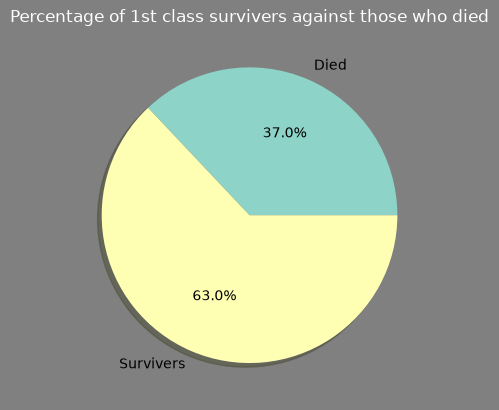

In [462]:
condition1 = np.logical_and(titanic_df["Pclass"] == 1, titanic_df["Survived"] == 1)
general_condition = np.logical_or(titanic_df["Age"] < 18, titanic_df["Sex"] == "female")
condition3 = np.logical_and(titanic_df["Pclass"] == 3, titanic_df["Survived"] == 1)

class_1 = titanic_df[titanic_df["Pclass"] == 1]
survivors_1_class = titanic_df[condition1]
sizes1 = [len(class_1.index) - len(survivors_1_class.index),len(survivors_1_class.index)]

class_3 = titanic_df[titanic_df["Pclass"] == 3]
survivors_3_class = titanic_df[condition3]


fig = plt.figure(facecolor='grey')
plt.pie(sizes1,labels=["Died","Survivers"],autopct='%1.1f%%', shadow=True, textprops={'color': 'black'})
plt.title("Percentage of 1st class survivers against those who died")
plt.show()



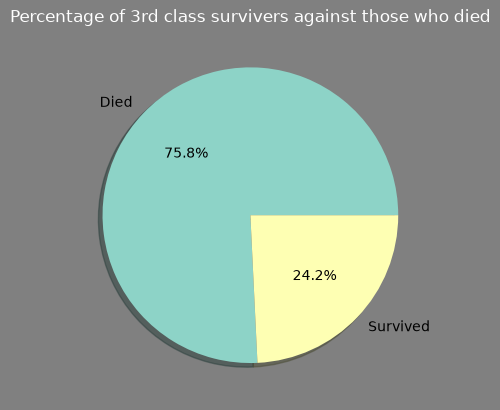

In [463]:
sizes3 = [len(class_3.index) - len(survivors_3_class.index),len(survivors_3_class.index)]
fig = plt.figure(facecolor='grey')
plt.pie(sizes3,labels=["Died","Survived"],autopct='%1.1f%%',textprops={'color': 'black'},shadow=True)
plt.title("Percentage of 3rd class survivers against those who died")

plt.show()


Now, the main question was about to get an answer. Next, we can get the percantage of survivers in every class

C:\Users\Sasko\AppData\Local\Temp\ipykernel_15652\2026153950.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  survivors_1_class_women = survivors_1_class[general_condition]


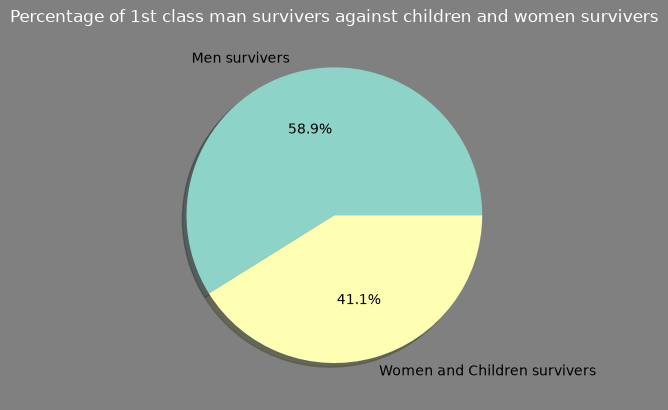

In [464]:
survivors_1_class_men = survivors_1_class["Sex"]=="male"
survivors_1_class_women = survivors_1_class[general_condition]
fig = plt.figure(facecolor='grey')
ratio1 = [len(survivors_1_class_men.index), len(survivors_1_class_women.index)]
plt.pie(ratio1,labels=["Men survivers", "Women and Children survivers"],autopct='%1.1f%%',textprops={'color': 'black'}, shadow=True)
plt.title("Percentage of 1st class man survivers against children and women survivers")

plt.show()





C:\Users\Sasko\AppData\Local\Temp\ipykernel_15652\1708308270.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  survivors_3_class_women = survivors_3_class[general_condition]


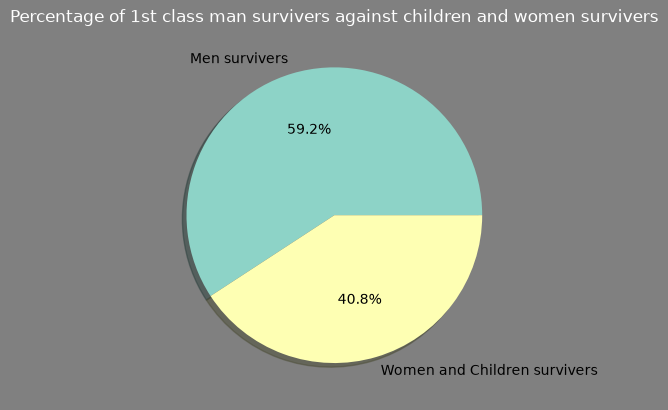

In [465]:
survivors_3_class_men = survivors_3_class["Sex"]=="male"
survivors_3_class_women = survivors_3_class[general_condition]
ratio2 = [len(survivors_3_class_men), len(survivors_3_class_women)]
fig = plt.figure(facecolor='grey')
plt.pie(ratio2,labels=["Men survivers", "Women and Children survivers"],autopct='%1.1f%%',textprops={'color': 'black'},shadow=True)
plt.title("Percentage of 3rd class man survivers against children and women survivers")
plt.show()


Although the percentage is a bit higher in the 1st class, but we have to consider the fact that in the 1st class more people have survived, so we cannot make our decision about kindness of people

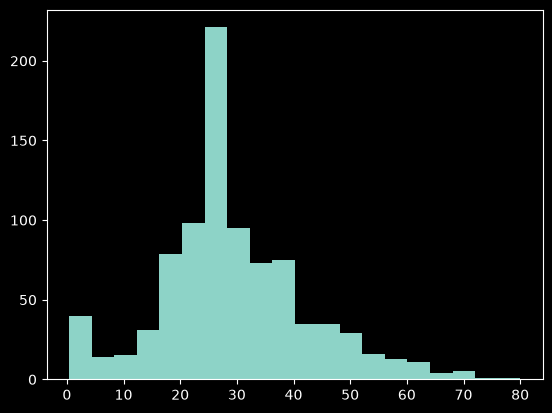

In [481]:
plt.hist(titanic_df["Age"],bins = 20)
plt.title("Age distribution on the Titanic")
plt.show()

It was important to build to examine to see amount of people of different ages on the ship

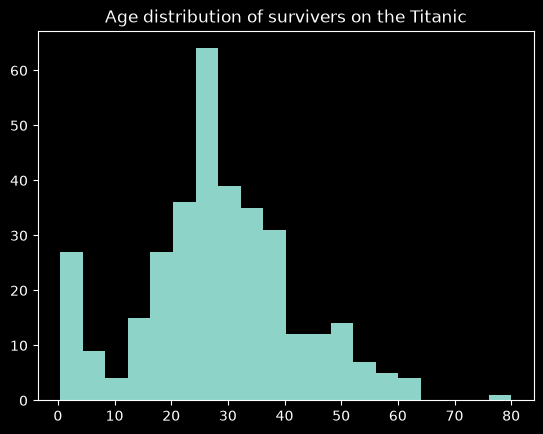

In [490]:
plt.hist(titanic_df.loc[titanic_df["Survived"] == 1,"Age"],bins = 20)
plt.title("Age distribution of survivers on the Titanic")
plt.show()

Then for better understanding of correlations, it was discovered how many people of different ages have survived

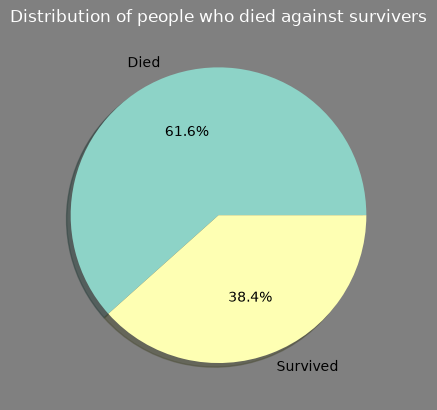

In [492]:
all_class_survivors = titanic_df[titanic_df["Survived"] == 1]
ratio_total = [len(titanic_df.index) - len(all_class_survivors.index), len(all_class_survivors.index)]
fig = plt.figure(facecolor='grey')
plt.pie(ratio_total,labels=["Died","Survived"],autopct='%1.1f%%',textprops={'color': 'black'},shadow=True)
plt.title("Distribution of people who died against survivers")
plt.show()

To make a good research, pie chart of general survivers in the titanic, undependtly of other conditions, was built.

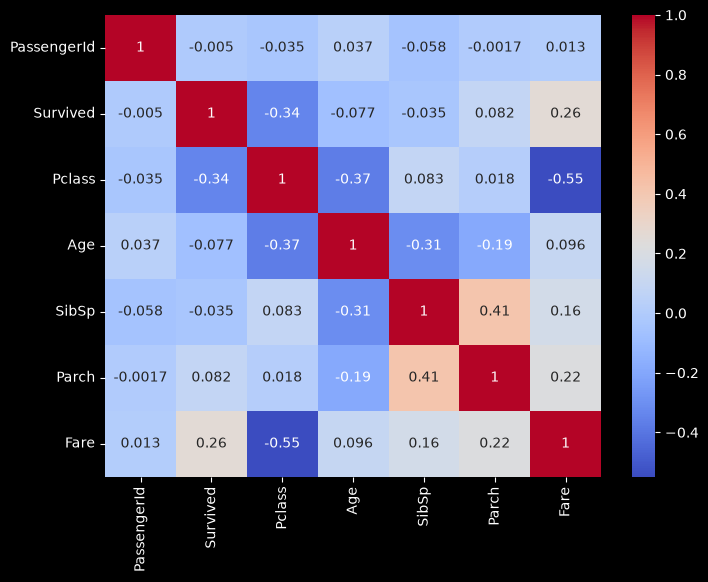

In [468]:
import seaborn as sns

corr = titanic_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

The correlation matrix was added, to understand the dependencies in the table. It helps to choose features for building a good model.

In [469]:
titanic_df["Sex"] = titanic_df["Sex"].replace({"male": 0, "female": 1})

Age_class1_mean = int(titanic_df["Age"][titanic_df["Pclass"] == 1].mean())
Age_class2_mean = int(titanic_df["Age"][titanic_df["Pclass"] == 2].mean())
Age_class3_mean = int(titanic_df["Age"][titanic_df["Pclass"] == 3].mean())

titanic_df.loc[titanic_df["Pclass"] == 1, "Age"] = titanic_df.loc[titanic_df["Pclass"] == 1, "Age"].fillna(Age_class1_mean)
titanic_df.loc[titanic_df["Pclass"] == 2, "Age"] = titanic_df.loc[titanic_df["Pclass"] == 2, "Age"].fillna(Age_class2_mean)
titanic_df.loc[titanic_df["Pclass"] == 3, "Age"] = titanic_df.loc[titanic_df["Pclass"] == 3, "Age"].fillna(Age_class3_mean)







In [470]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


In [471]:
model1 = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)
features = [
    "Pclass",
    "Age",
    "Sex",
    "Fare",
    "Parch",
    "SibSp"
]
X = titanic_df[features]
y = titanic_df["Survived"]
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=64)
model1.fit(train_X, train_y)
y_pred = model1.predict(test_X)

model1_score = cross_val_score(model1, X, y, cv=5, scoring='accuracy')







In [472]:
model2 = LogisticRegression(solver="lbfgs", C=0.5)
model2.fit(train_X,train_y)
y2_pred = model2.predict(test_X)
model2_score = cross_val_score(model2, X, y, cv=5, scoring='accuracy')


In [473]:
model_final = model1
print(model1_score)
print(model2_score)
if model2_score.mean() > model1_score.mean():
    model_final = model2
model_final.fit(X,y)

[0.7877095  0.80898876 0.8258427  0.79213483 0.83707865]
[0.79329609 0.80337079 0.79775281 0.7752809  0.81460674]


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

Two different models were created, evaluated, and chosen for the final csv with the predictions of survival rate

In [474]:
titanic_df_test = pd.read_csv("test.csv")
titanic_df_test.loc[titanic_df_test["Pclass"] == 1, "Age"] = titanic_df_test.loc[titanic_df_test["Pclass"] == 1, "Age"].fillna(Age_class1_mean)
titanic_df_test.loc[titanic_df_test["Pclass"] == 2, "Age"] = titanic_df_test.loc[titanic_df_test["Pclass"] == 2, "Age"].fillna(Age_class2_mean)
titanic_df_test.loc[titanic_df_test["Pclass"] == 3, "Age"] = titanic_df_test.loc[titanic_df_test["Pclass"] == 3, "Age"].fillna(Age_class3_mean)
titanic_df_test["Sex"] = titanic_df_test["Sex"].replace({"male": 0, "female": 1})

titanic_df_test["Fare"] = titanic_df_test["Fare"].fillna(titanic_df["Fare"].mean())


In [475]:
X_final = titanic_df_test[features]
y_pred_final = model_final.predict(X_final)
#roc_auc_score(test_y, y_pred_final)

output = pd.DataFrame({'PassengerId': titanic_df_test.PassengerId,
                       'Survived': y_pred_final})
output.to_csv('submission_final_newww2.csv', index=False)
